2. Data Analysis and Visualization
- Identify categorical, ordinal, and numerical variables within the data
- Provide measures of centrality and distribution with visualizations
- Diagnose for correlations between variables and determine independent and dependent variables
- Perform exploratory analysis in combination with visualization techniques to discover patterns and features of interest

In [189]:
# Import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [192]:
# Import the dataset using pandas read_csv
df = pd.read_csv("cleaned_house_sales.csv")

# Ensure head displays all columns
pd.set_option('display.max_columns', None)

# Display the top 5 rows
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,house_age,renovated_bool,log_price,log_sqft_lot,log_sqft_lot15,living_lot_ratio,sale_month,grade_level,condition_level
0,221900.0,3,1.00,1180,5650.0,1.0,0,0,3,7,1180,0,1340,5650,59,0,12.3100,8.6394,8.6394,0.209,10,Mid,Average
1,538000.0,3,2.25,2570,7242.0,2.0,0,0,3,7,2170,400,1690,7639,63,1,13.1956,8.8877,8.9410,0.355,12,Mid,Average
2,180000.0,2,1.00,770,10000.0,1.0,0,0,3,6,770,0,2720,8062,82,0,12.1007,9.2103,8.9949,0.077,2,Low,Average
3,604000.0,4,3.00,1960,5000.0,1.0,0,0,5,7,1050,910,1360,5000,49,0,13.3113,8.5172,8.5172,0.392,12,Mid,Good
4,510000.0,3,2.00,1680,8080.0,1.0,0,0,3,8,1680,0,1800,7503,28,0,13.1422,8.9971,8.9231,0.208,2,Mid,Average


In [175]:
# Display the shape of the dataframe
original_shape = df.shape
print(original_shape)

# Display count by data type
df.dtypes.value_counts()

(21096, 23)


int64      13
float64     8
object      2
Name: count, dtype: int64

In [176]:
# Display the shape of the dataframe
original_shape = df.shape
print(original_shape)

# Display count by data type
df.dtypes.value_counts()

# Display column number, column name, non-null count, and data type
df.info()

(21096, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21096 entries, 0 to 21095
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             21096 non-null  float64
 1   bedrooms          21096 non-null  int64  
 2   bathrooms         21096 non-null  float64
 3   sqft_living       21096 non-null  int64  
 4   sqft_lot          21096 non-null  float64
 5   floors            21096 non-null  float64
 6   waterfront        21096 non-null  int64  
 7   view              21096 non-null  int64  
 8   condition         21096 non-null  int64  
 9   grade             21096 non-null  int64  
 10  sqft_above        21096 non-null  int64  
 11  sqft_basement     21096 non-null  int64  
 12  sqft_living15     21096 non-null  int64  
 13  sqft_lot15        21096 non-null  int64  
 14  house_age         21096 non-null  int64  
 15  renovated_bool    21096 non-null  int64  
 16  log_price         21096 non-

In [177]:
# Calculate descriptive statistics including Skewness
stats = df.describe().T
stats['skew'] = df.select_dtypes(include=[np.number]).skew()
stats['kurtosis'] = df.select_dtypes(include=[np.number]).kurt()

print("--- Descriptive Statistics with Skewness ---")
display(stats[['mean', '50%', 'std', 'min', 'max', 'skew', 'kurtosis']])

--- Descriptive Statistics with Skewness ---


,mean,50%,std,min,max,skew,kurtosis
price,503173.983646,445000.0000,253387.110186,78000.0000,1.612500e+06,1.340454,2.189061
bedrooms,3.348881,3.0000,0.885806,1.0000,7.000000e+00,0.345404,0.523625
bathrooms,2.077384,2.2500,0.723953,0.5000,5.750000e+00,0.220151,-0.062117
sqft_living,2017.882205,1890.0000,809.695826,370.0000,5.860000e+03,0.831547,0.690102
sqft_lot,14406.884528,7600.0000,38819.074087,520.0000,1.651359e+06,13.470232,319.241269
floors,1.485519,1.0000,0.538529,1.0000,3.500000e+00,0.647396,-0.442194
waterfront,0.004314,0.0000,0.065538,0.0000,1.000000e+00,15.128154,226.882563
view,0.201507,0.0000,0.699791,0.0000,4.000000e+00,3.636394,12.802154
condition,3.408466,3.0000,0.649147,1.0000,5.000000e+00,1.031639,0.531297
grade,7.591439,7.0000,1.088534,4.0000,1.100000e+01,0.576137,0.628026


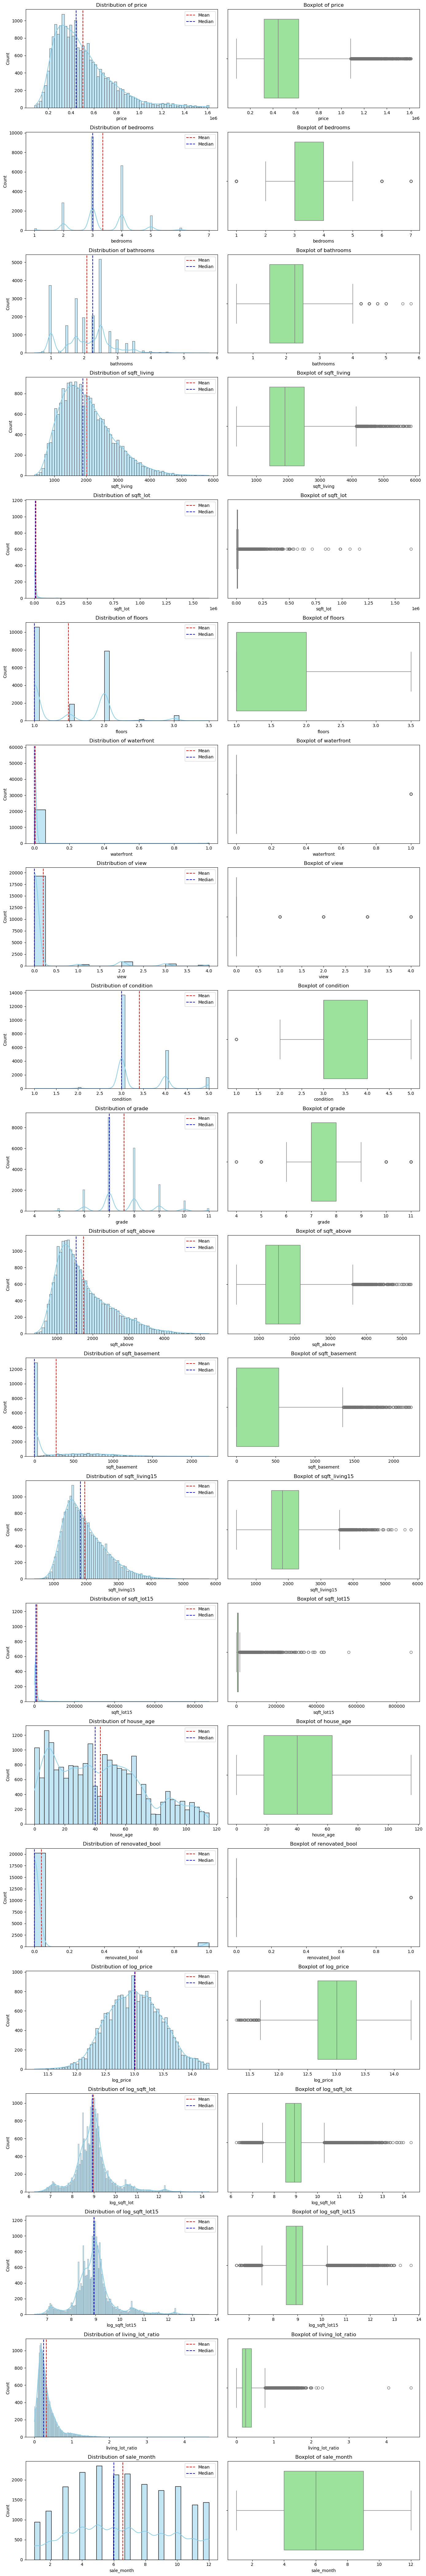

In [178]:
numeric_df = df.select_dtypes(include=['number'])
cols = [c for c in numeric_df.columns if c.lower() != 'id']

fig, axes = plt.subplots(len(cols), 2, figsize=(14, 4 * len(cols)))

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    # Add a vertical line for the mean
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i, 0].axvline(df[col].median(), color='blue', linestyle='--', label='Median')
    axes[i, 0].legend()

    # 2. Boxplot (Centrality, Quartiles, & Outliers)
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

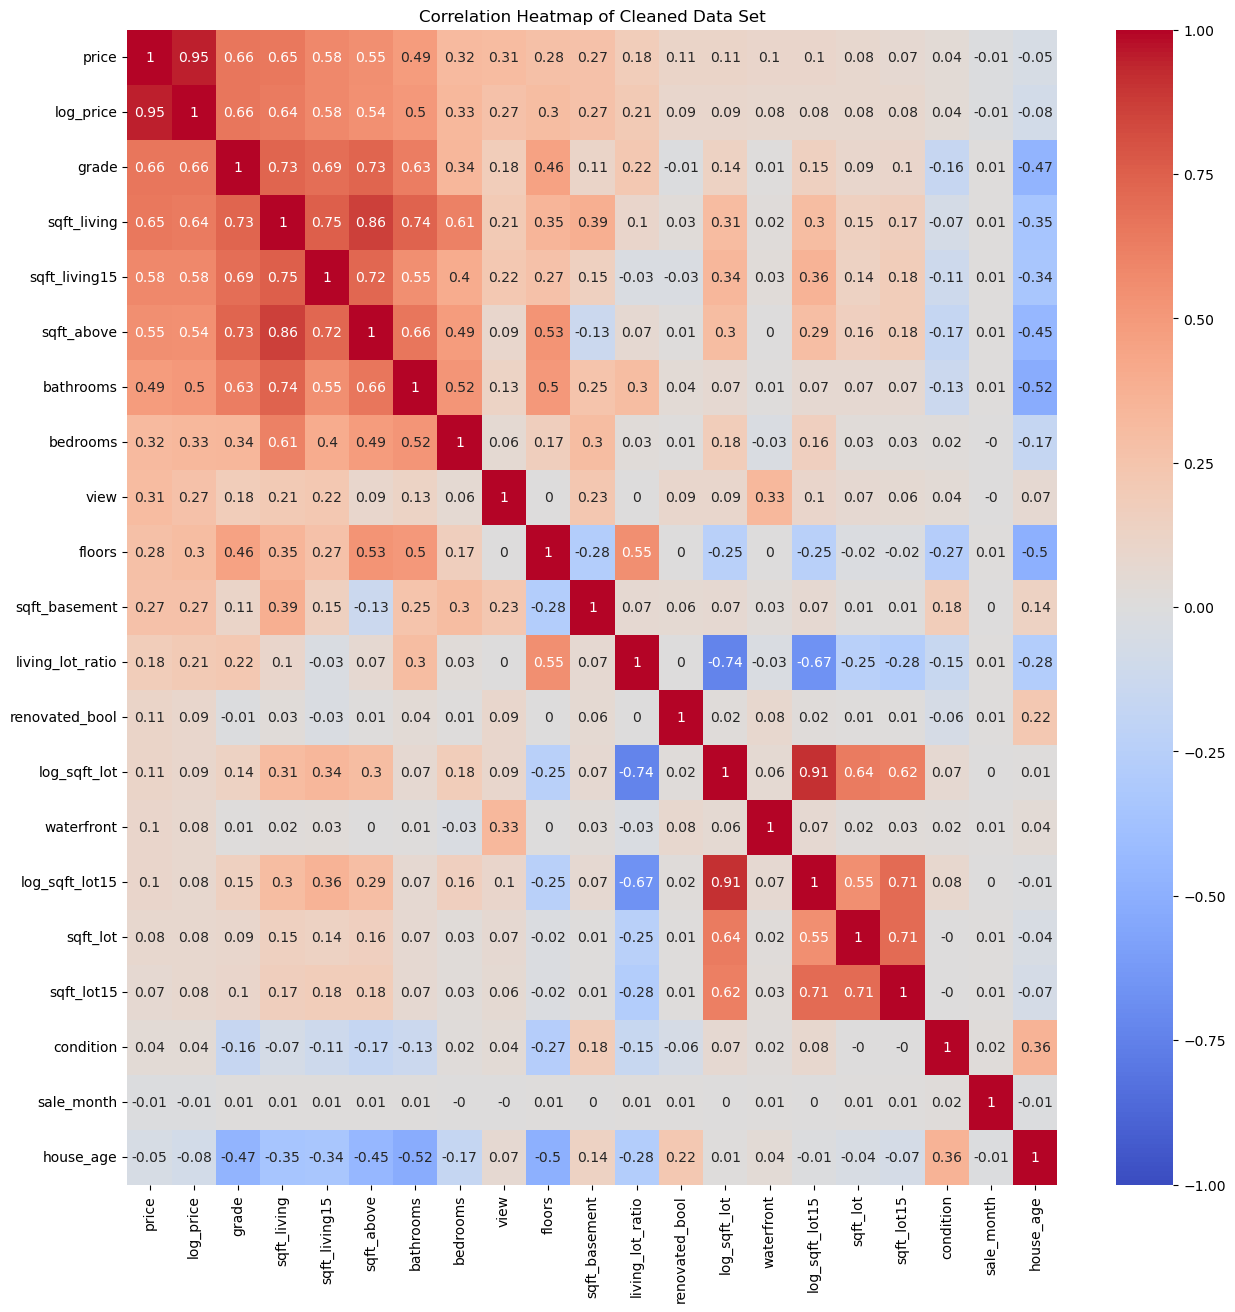

In [179]:
corr_matrix = df.corr(numeric_only = True).round(2)

price_corr_sorted = corr_matrix['price'].sort_values(ascending=False)
corr_matrix_sorted = corr_matrix.loc[price_corr_sorted.index, price_corr_sorted.index].round(2)

plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix_sorted, annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Correlation Heatmap of Cleaned Data Set')
plt.show()


The dependent variable is price, all other factors affect price, and not the other way around. If I paid double for a house, it would not magically grow more bedrooms, but if a house has more bedrooms, it is more expensive to purchase. All of these qualitative and quantitative factors effect how expensive a house is to purchase.

The independent variables we will end up using are harder to pin down. We should try all using stepwise regression, optimizing for out of sample model fit and mitigating the issues of multicollinearity (high VIF). Sale_month should likely be turned into 3 indicator variables (for quarter minus 1) or 11 indicator variables (12 months minus 1) due to very low correlation. Renovated_bool also doesn't look particularly strong, so it may be drop in stepwise regression, but its worth trying incase it is a valuable part of the model, but the variation in the dependent variable that could be explained by another stronger independent variable.

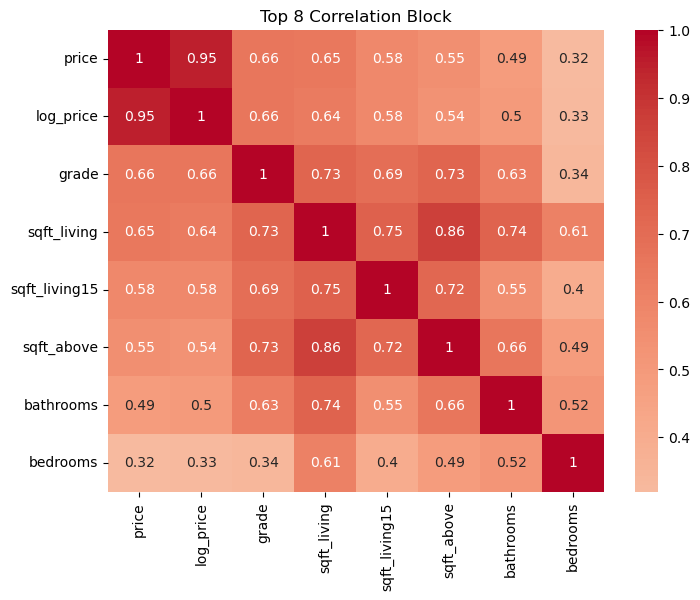

In [180]:
top_8_matrix = corr_matrix_sorted.iloc[:8, :8]
plt.figure(figsize=(8, 6))
sns.heatmap(top_8_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Top 8 Correlation Block')
plt.show()

Price is obviously correlated with log_price, we will never use log_price to predict price because that is circular logic, log_price just may be our dependent variable if it leads to a stronger model. Log_price is highly correlated with everything, with higher correlations with bathrooms and bedrooms when compared to price. Log_price has a lower correlation for sqft_living and sqft_above compared to price.

Grade is highly correlated with sqft_living and sqft_above, and moderately correlated with price, log_price, sqft_living15, bathrooms, and bedrooms. I have a feeling that because this has a high correlation with so many variables, it is a mediator variable (it can be predicted by other things), therefore we likely will end up excluding it.

sqft_living, sqft_living15, and sqft_above are very similar to grade, it has extremely high correlations across the board. We will likely have to pick one variable here so we do not overfit/ have multicollinearity.

bathrooms and bedrooms actually have relatively lower correlations, but still moderate across the board. Bedrooms and bathrooms has the highest correlation with sqft_living which makes sense. 

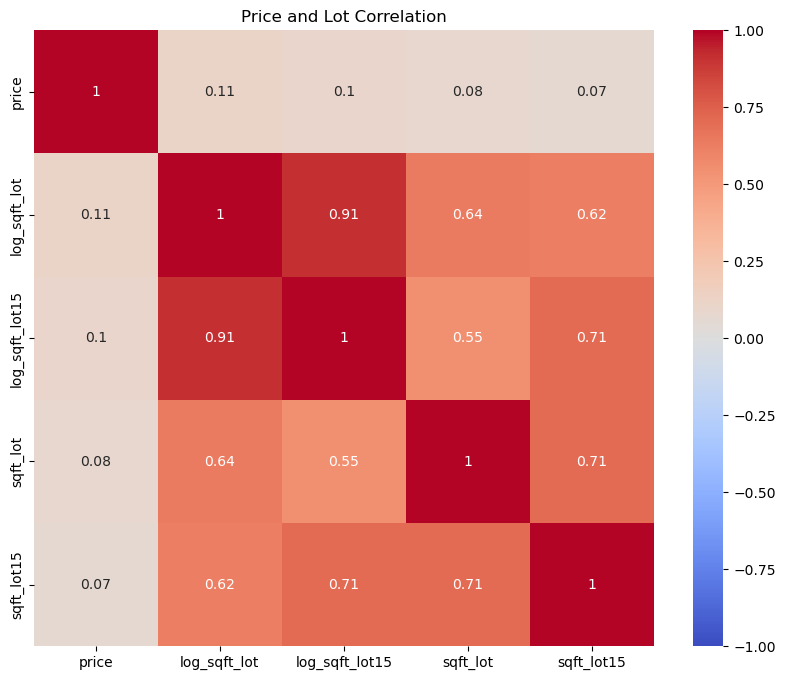

In [181]:
lot_cols = [col for col in corr_matrix_sorted.columns if 'lot' in col]
selection = ['price'] + lot_cols
lot_matrix = corr_matrix_sorted.loc[selection, selection]
lot_matrix = lot_matrix.drop(columns=['living_lot_ratio'], index=['living_lot_ratio'], errors='ignore')

plt.figure(figsize=(10, 8))
sns.heatmap(lot_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Price and Lot Correlation')
plt.show()

All of the lot variables (logged and normal) are moderately or highly correlated with one another, but not even moderately correlated with price. This means unless there is an extremely complex relationship, we likely won't be using these in our final model.

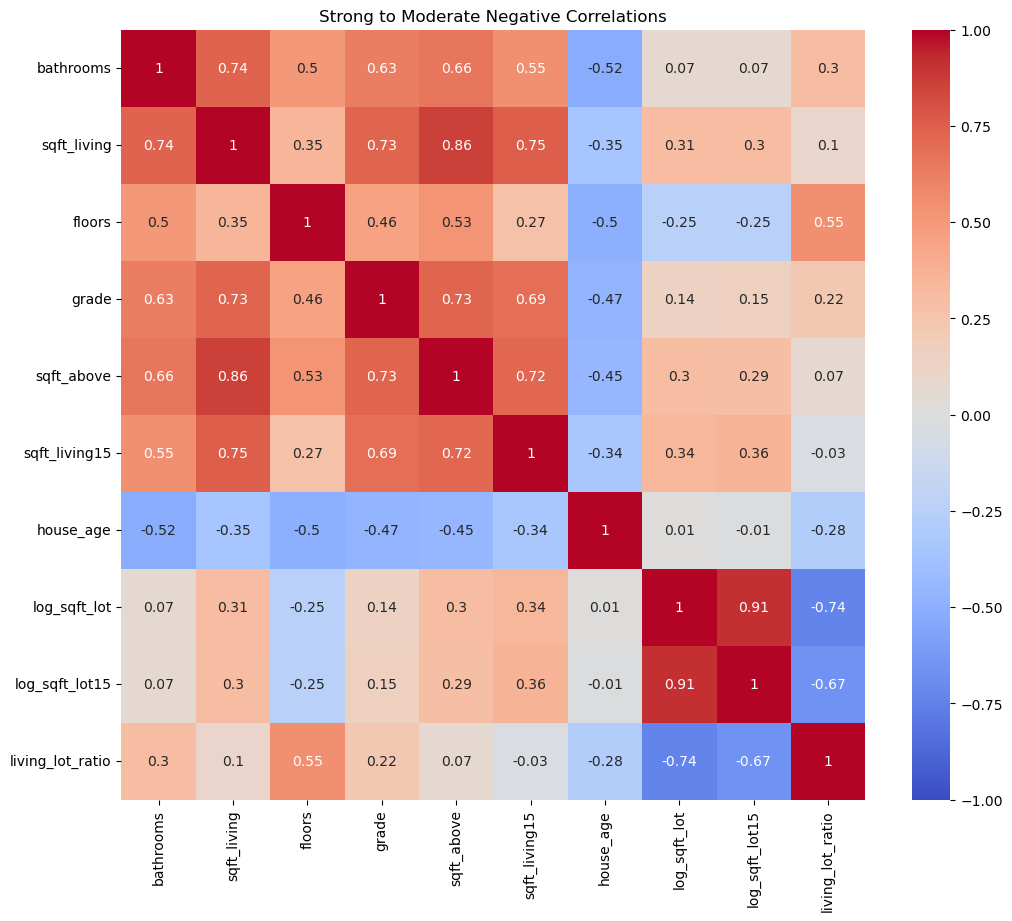

In [182]:
cols_to_keep = corr_matrix.columns[(corr_matrix < -0.3).any()]
selection = ['price'] + cols_to_keep
full_neg_context_df = corr_matrix.loc[cols_to_keep, cols_to_keep]

plt.figure(figsize=(12, 10))
sns.heatmap(full_neg_context_df, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            center=0)

plt.title('Strong to Moderate Negative Correlations')
plt.show()


house_age has a moderate negative correlation with bathrooms, sqft_living, floors, grade, sqft_above, and sqft_living15. This makes sense, the older a house is, it is likely to have fewer bathrooms, floors, and grade, also less living space. 

living_lot_ratio has a strong and moderate negative correlation with log_sqft_lot and log_sqft_lot15 respectively. This makes sense because as the living_lot_ratio gets larger that means that either the sqft_living gets larger, or the sqft_lot gets smaller. So as living_lot_ratio gets larger, the logged sqft_lot values get smaller. This makes sense as the ratio can only be large if the lot is small, there is an upper limit on house size, but not on lot size.

Interestingly living_lot_ratio does not have a strong correlation with the non-logged sqft_lot and sqft_lot15 metrics, this is an example where there is a clear log-log relationship. Including living_lot_ratio or a logged version of it could help the regression.

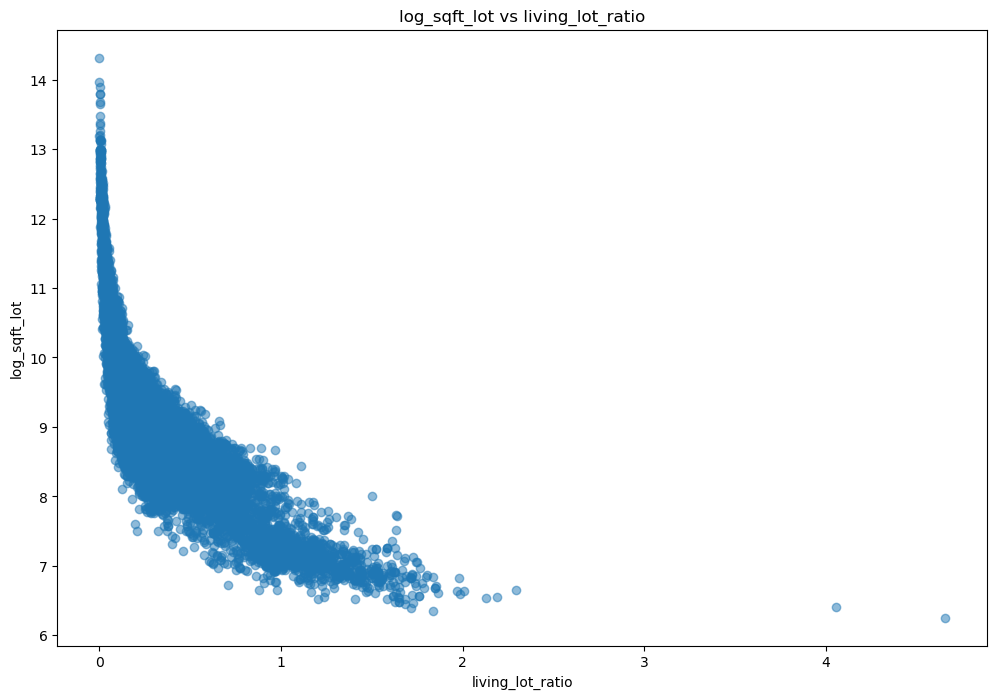

In [183]:
x = df['living_lot_ratio']
y = df['log_sqft_lot']

plt.figure(figsize=(12, 8))
plt.scatter(x, y, alpha = 0.5)
plt.xlabel('living_lot_ratio')
plt.ylabel('log_sqft_lot')
plt.title('log_sqft_lot vs living_lot_ratio')
plt.show()

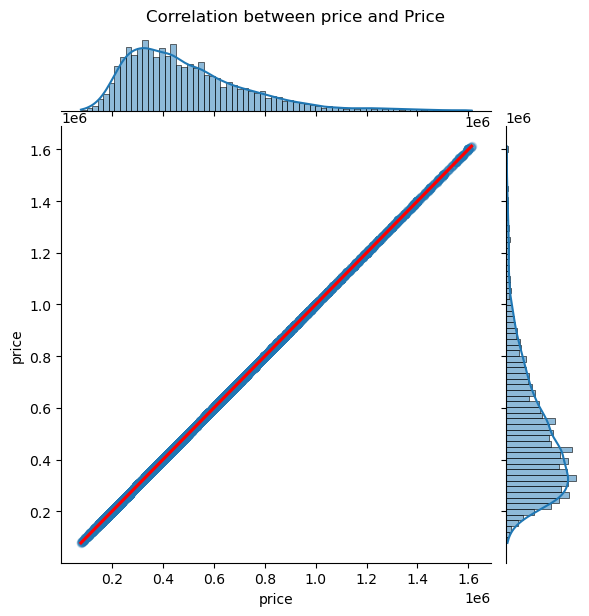

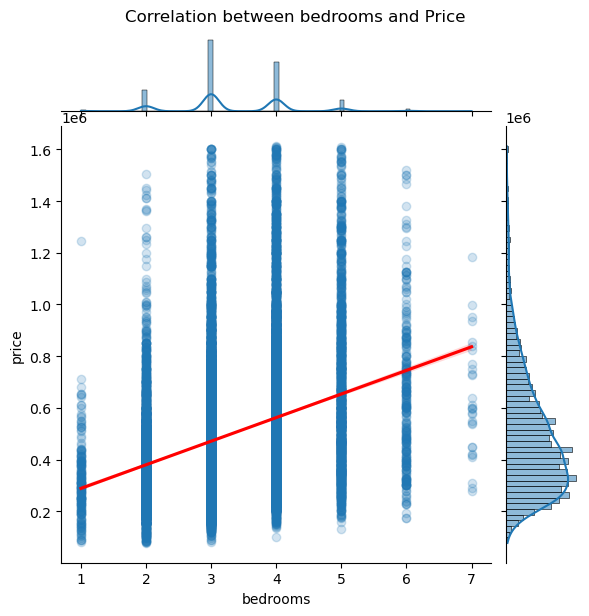

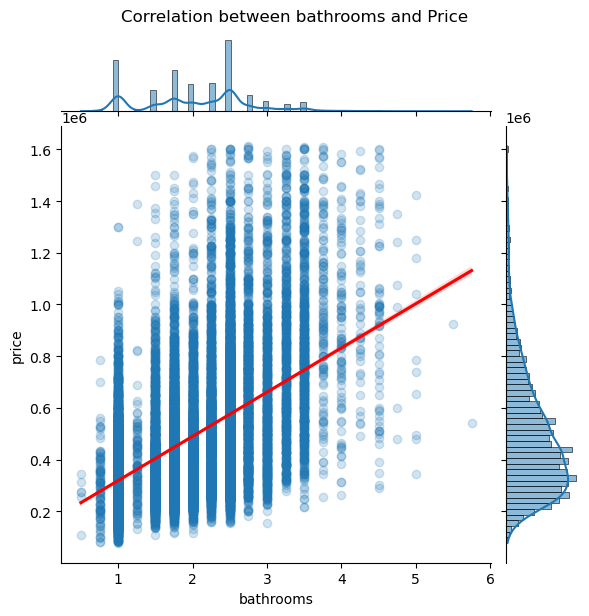

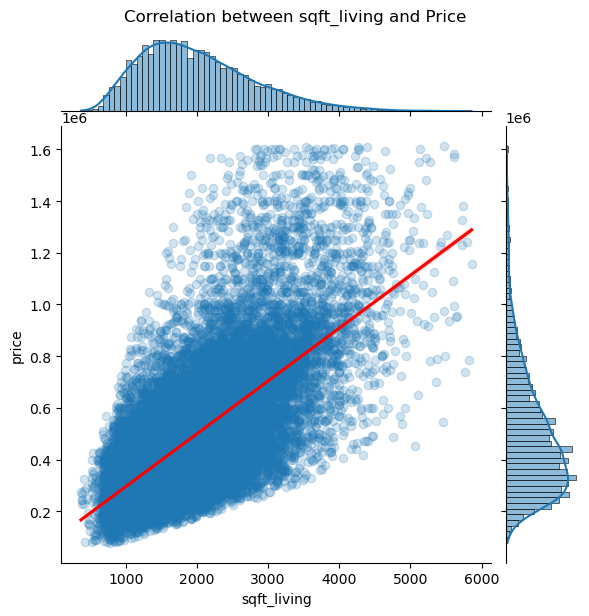

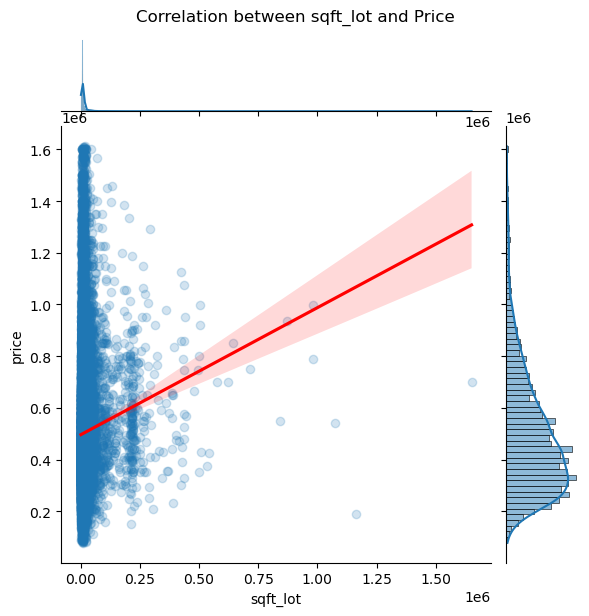

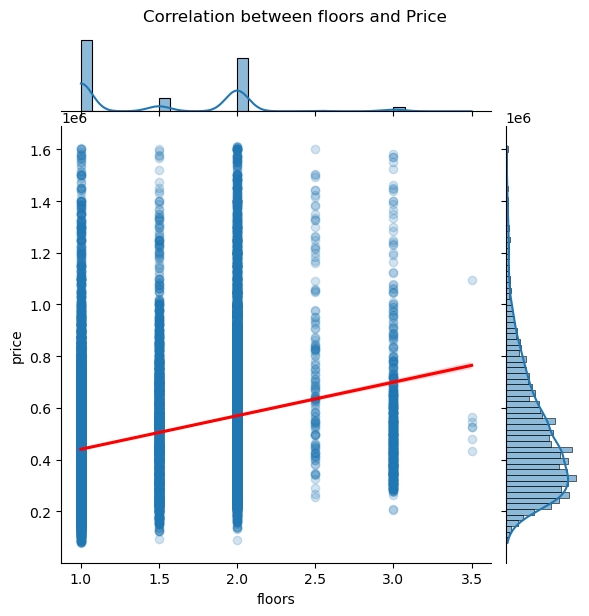

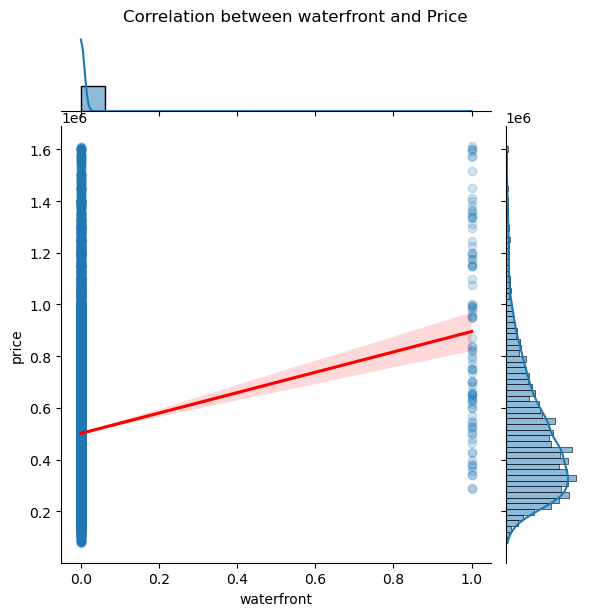

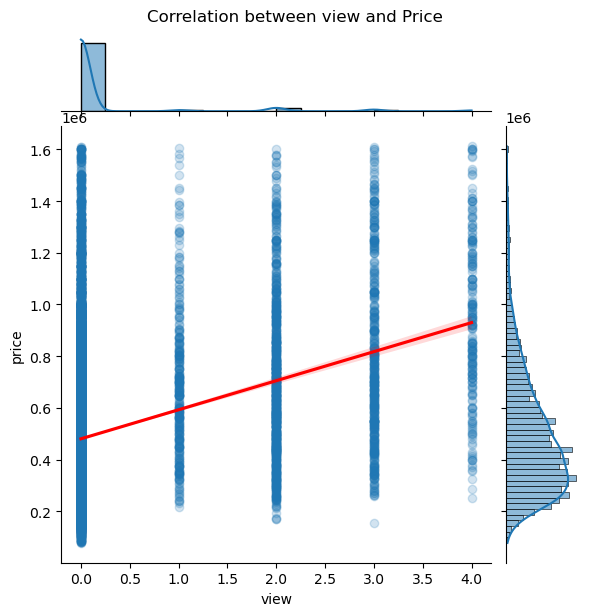

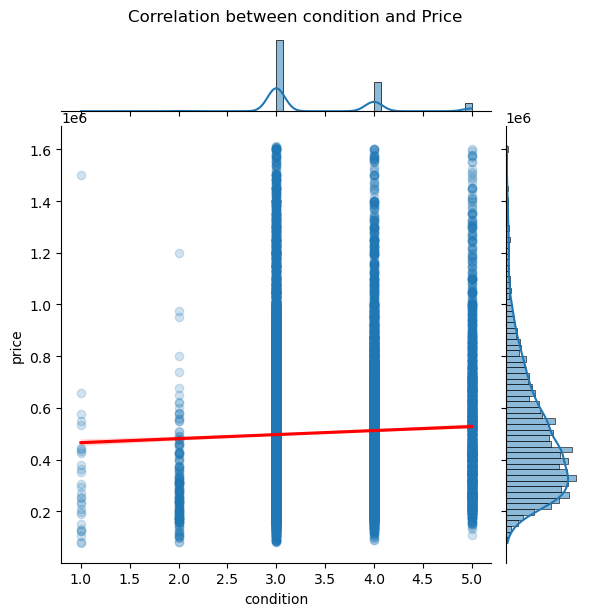

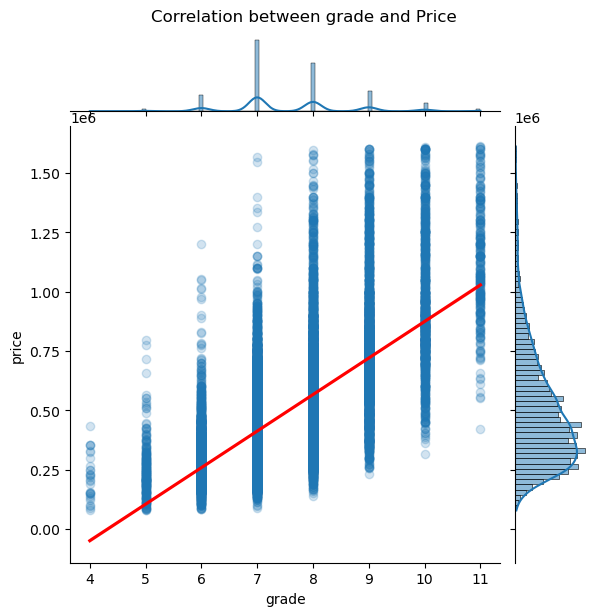

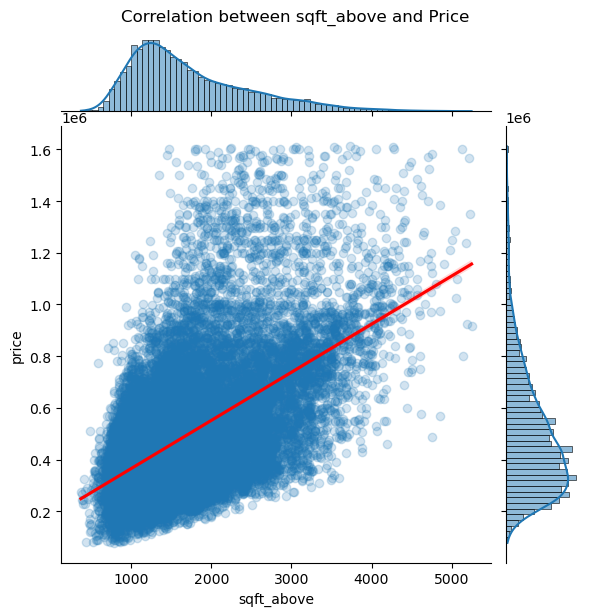

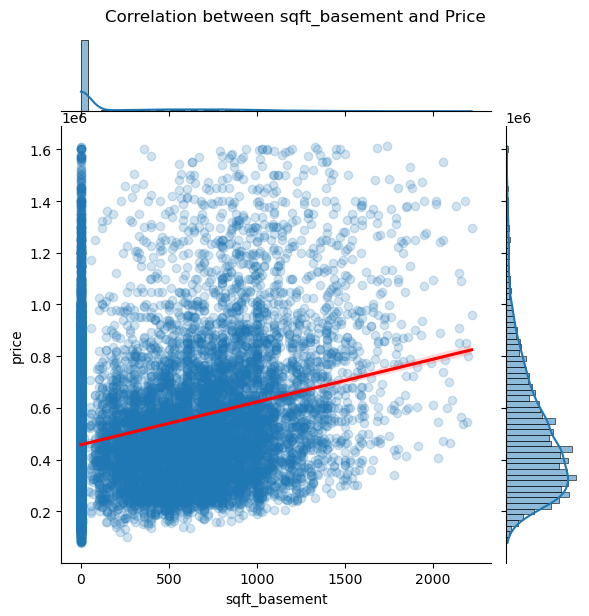

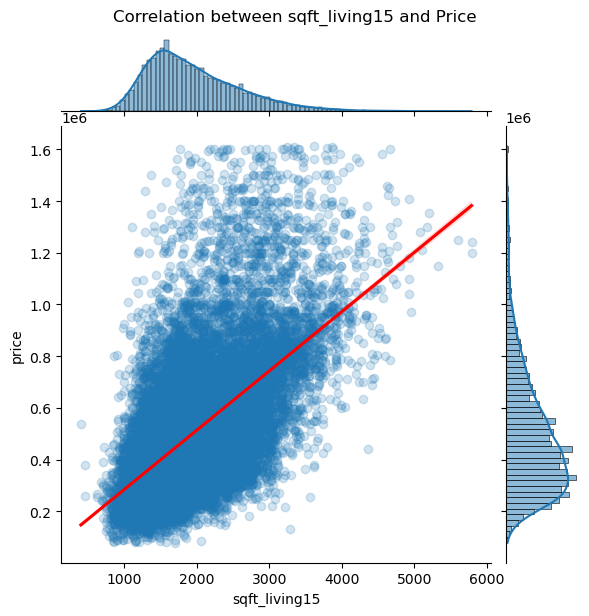

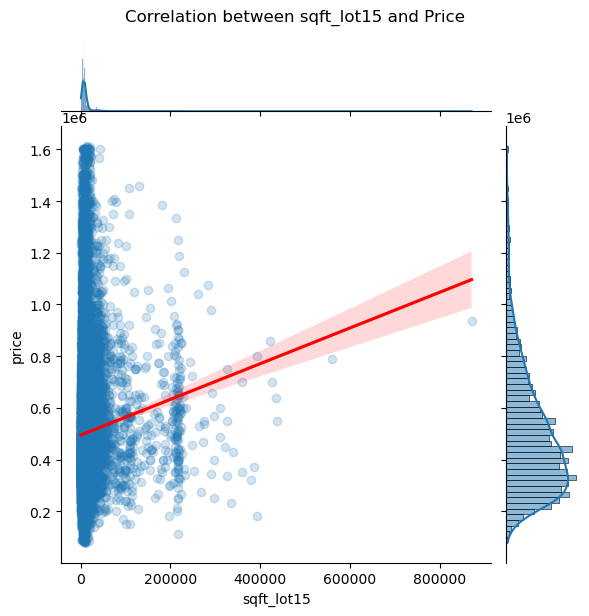

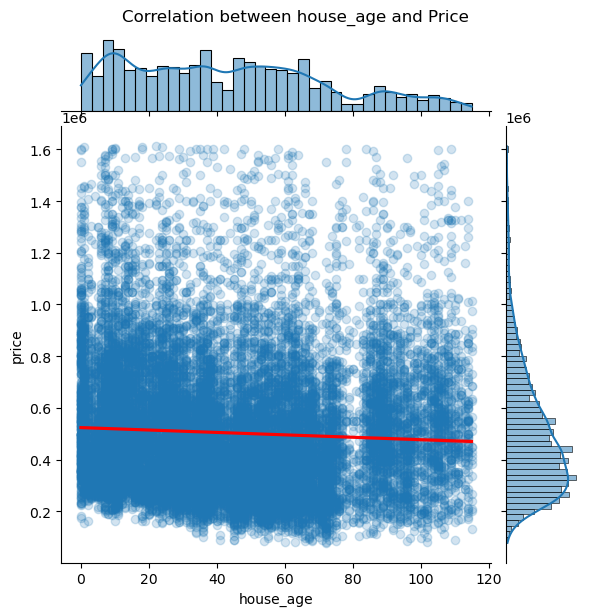

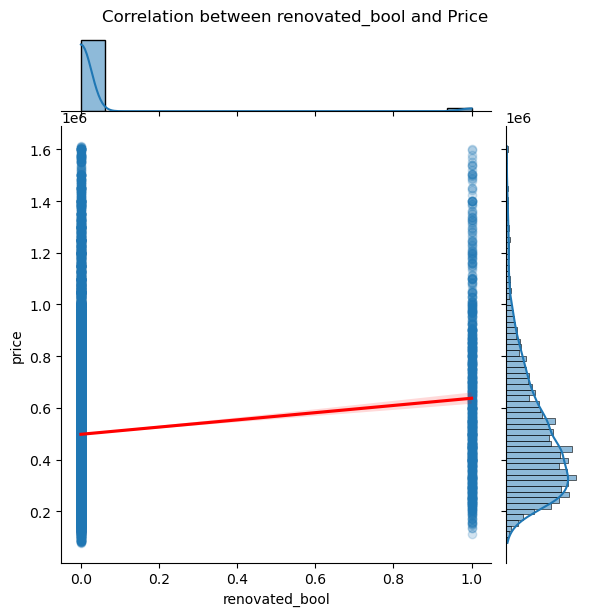

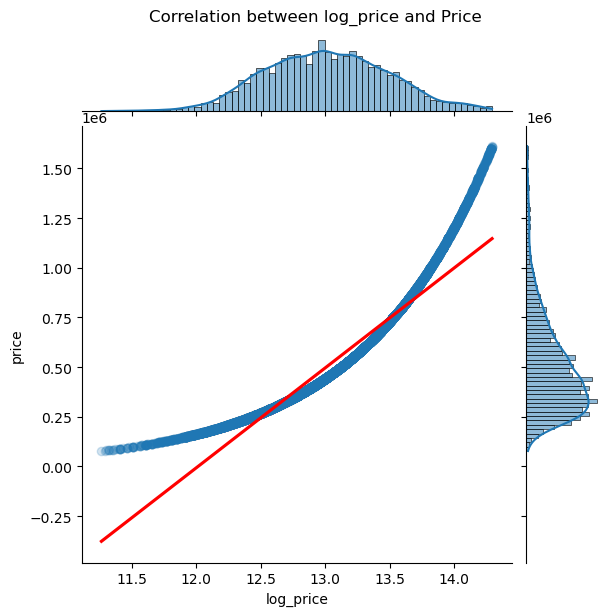

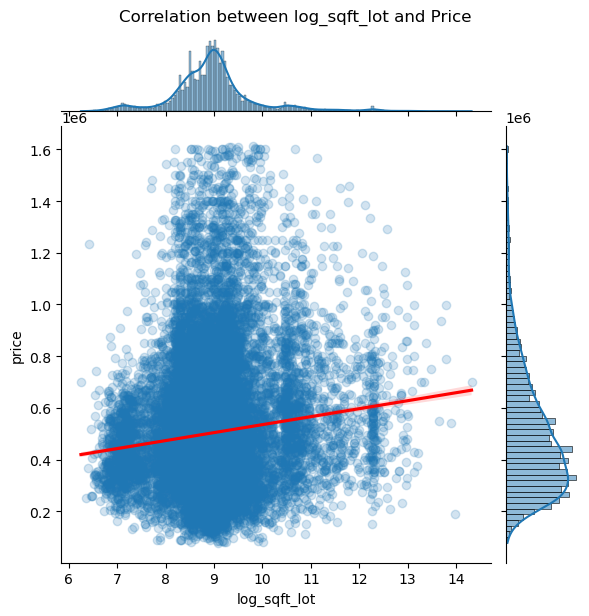

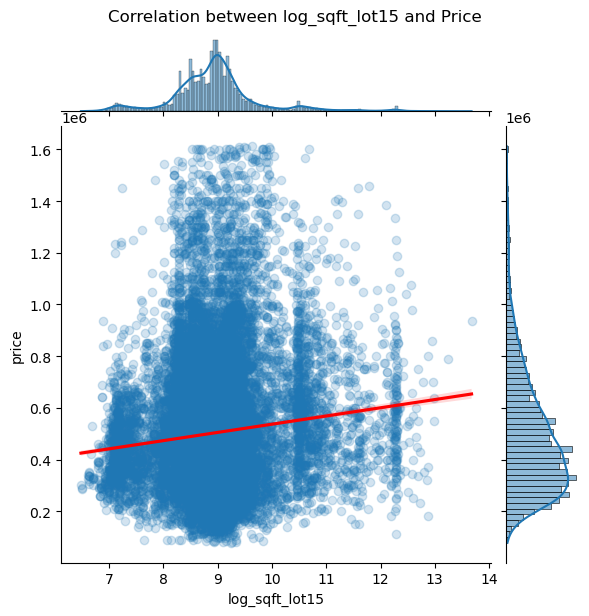

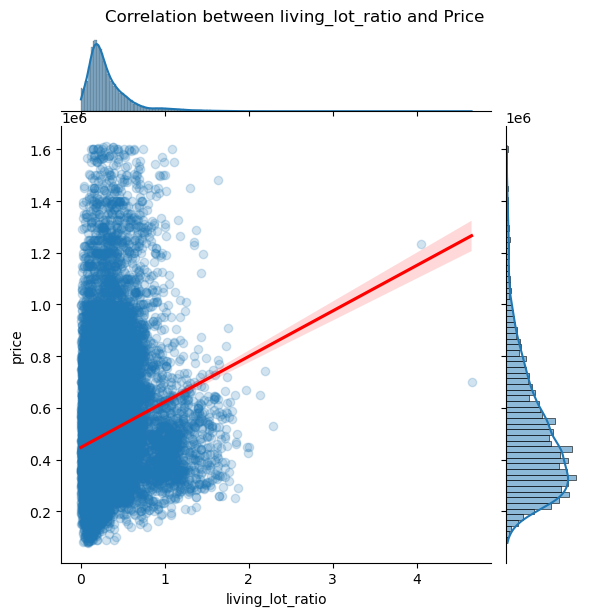

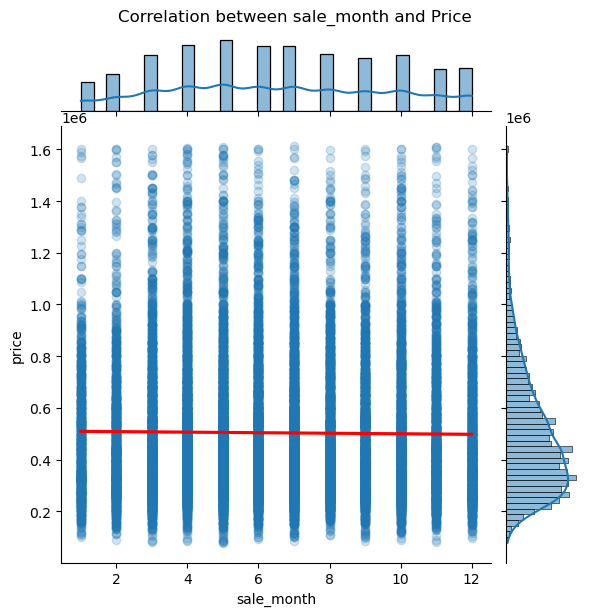

In [184]:
top_features = df.select_dtypes(include=['number']).columns

for feature in top_features:
    sns.jointplot(data=df, x=feature, y='price', kind='reg', 
                  scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
    plt.suptitle(f'Correlation between {feature} and Price', y=1.02)
    plt.show()

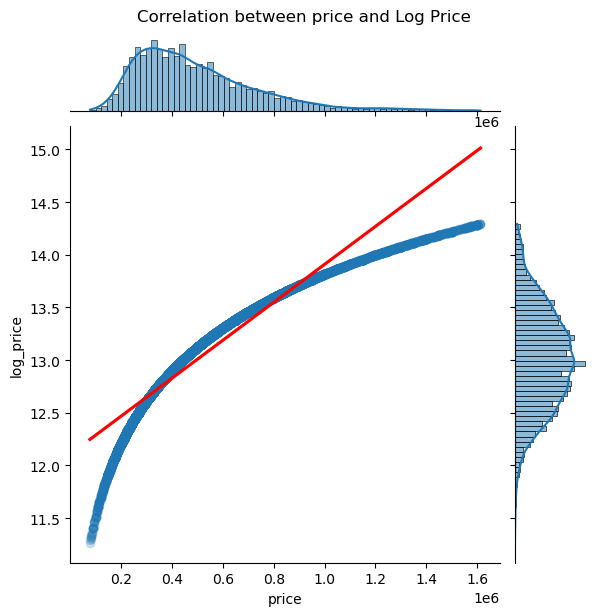

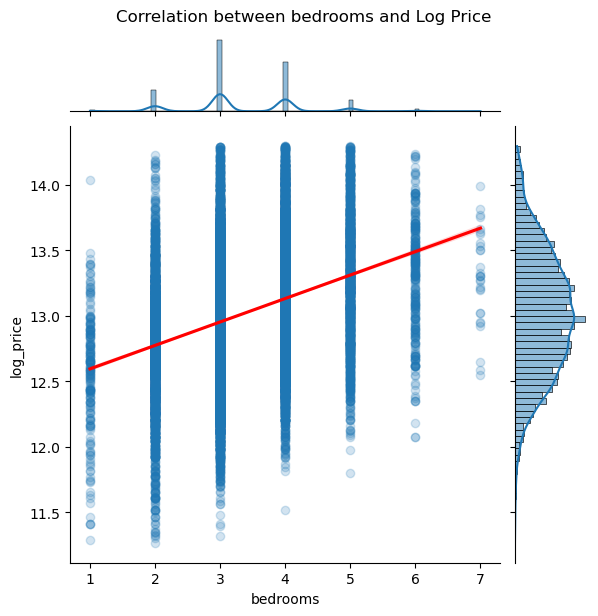

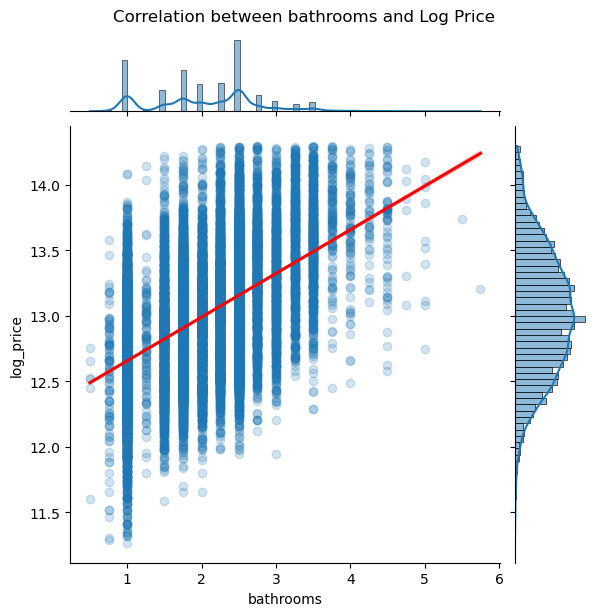

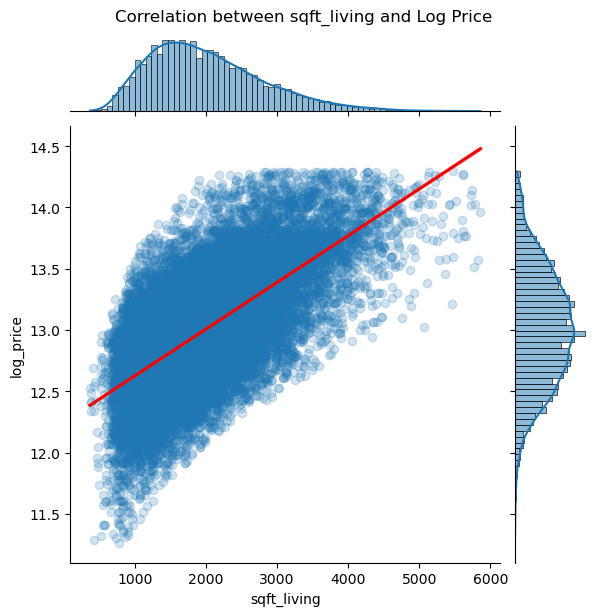

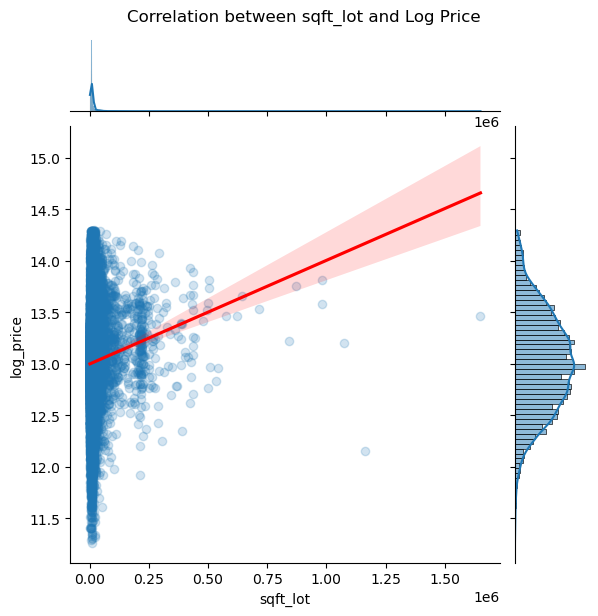

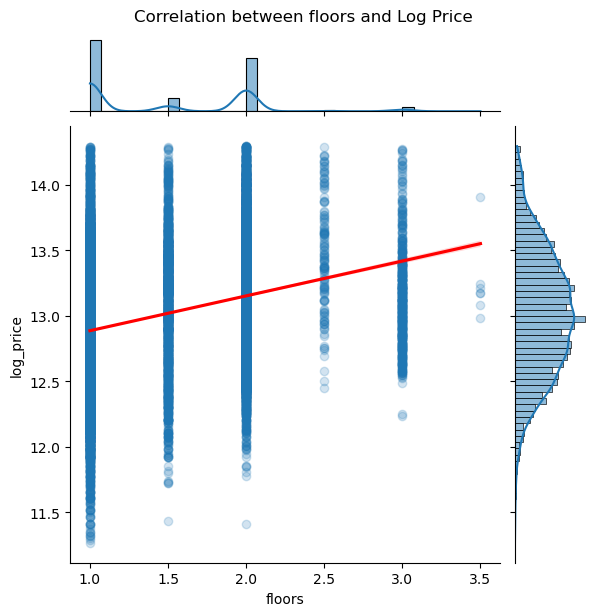

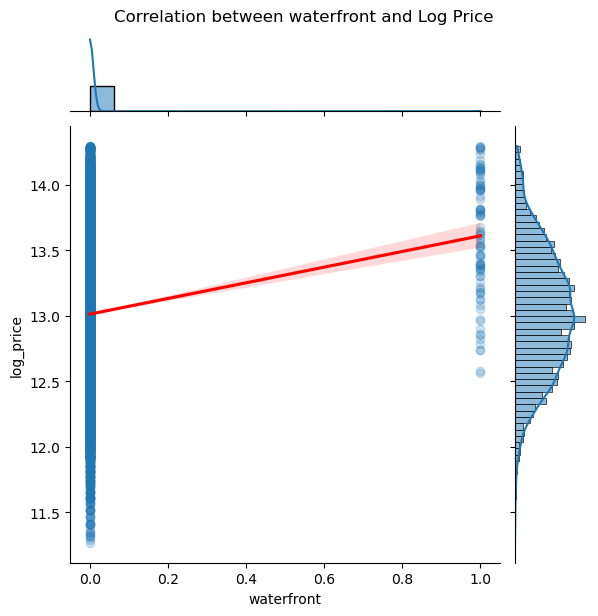

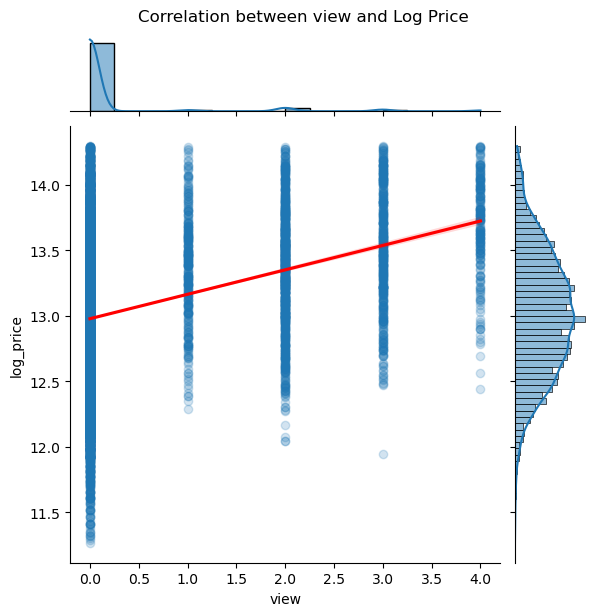

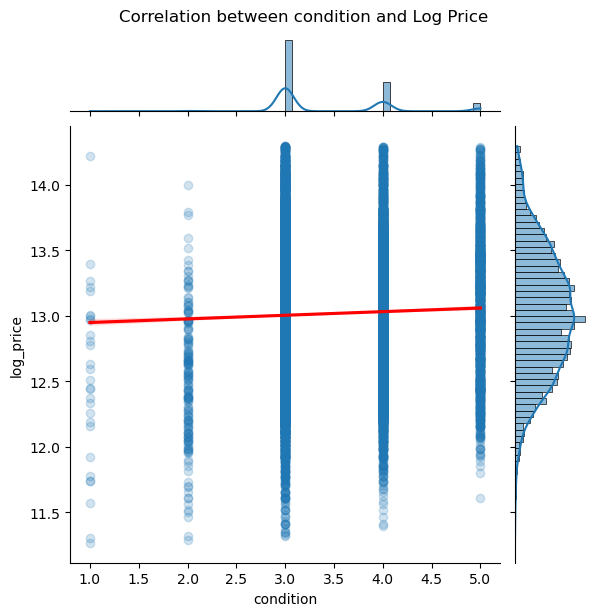

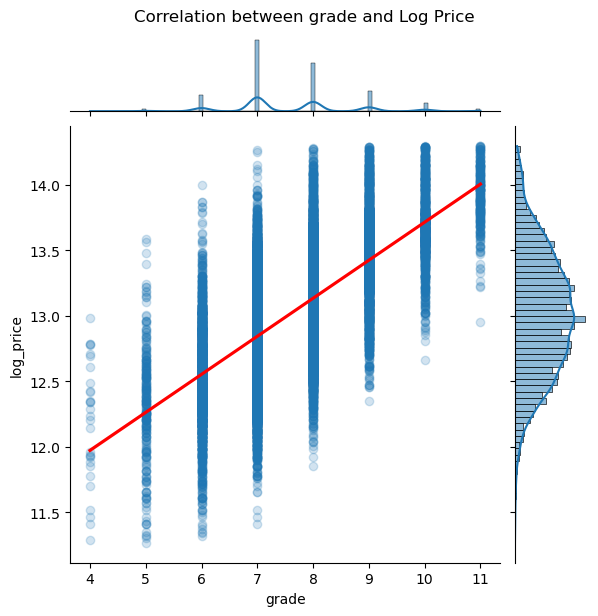

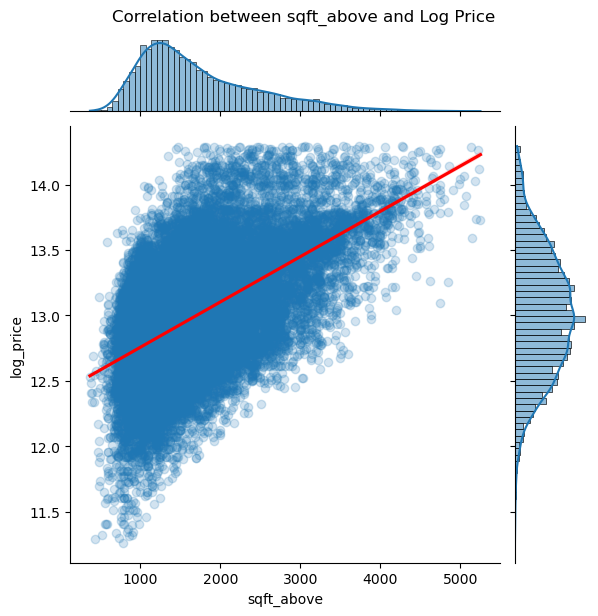

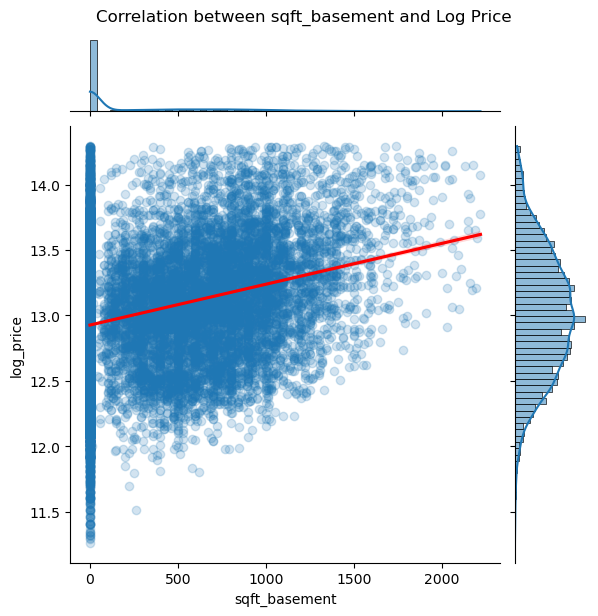

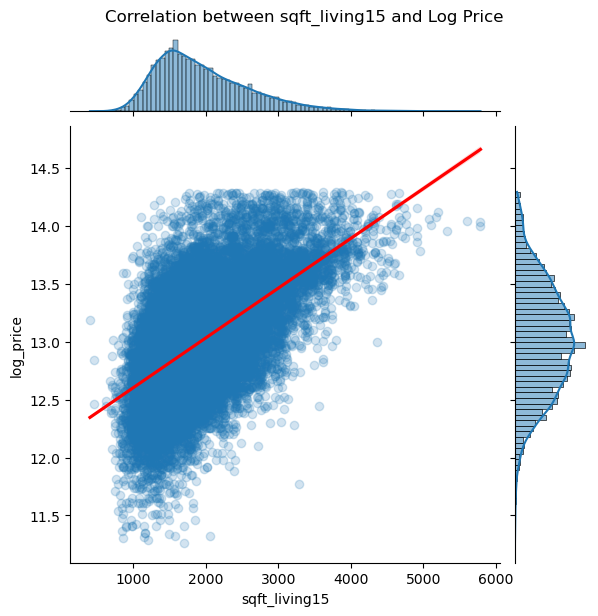

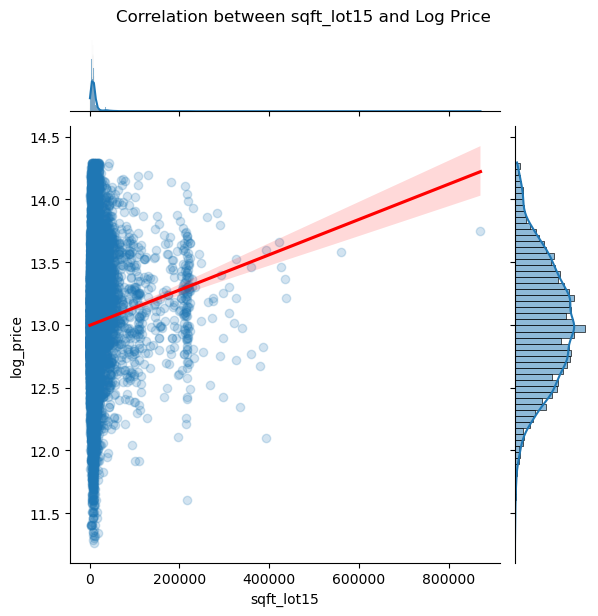

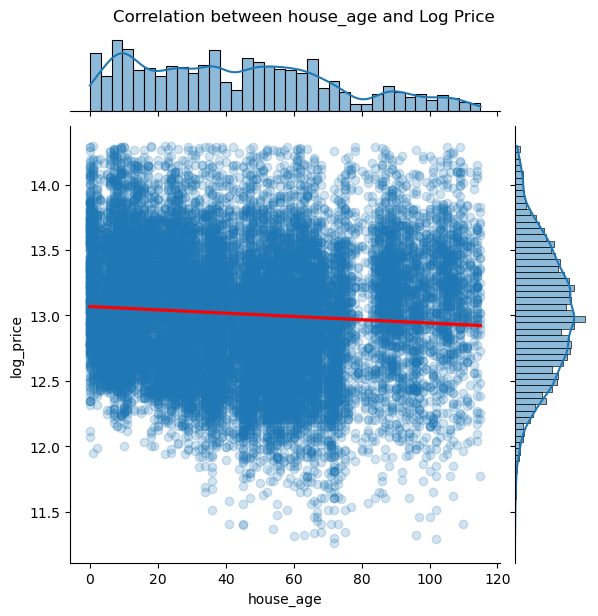

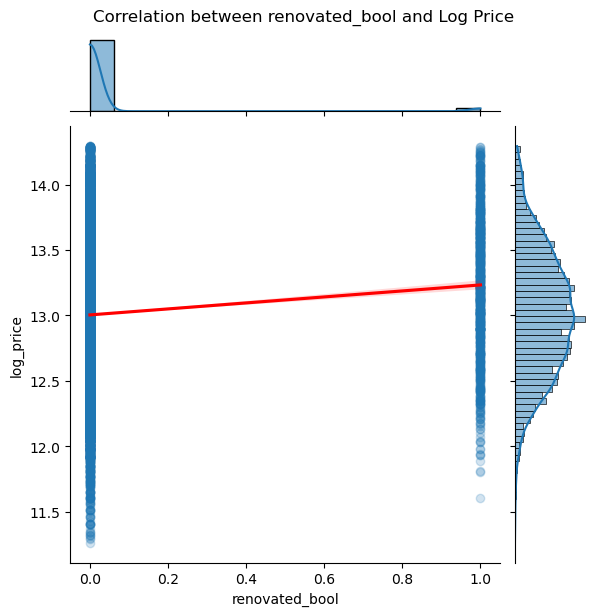

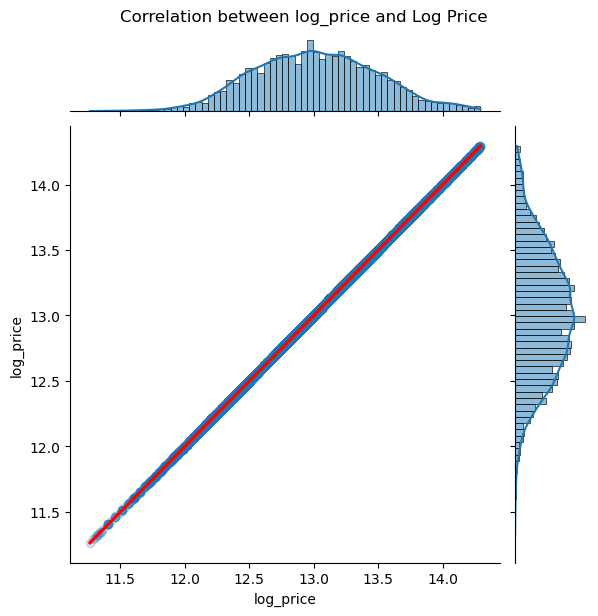

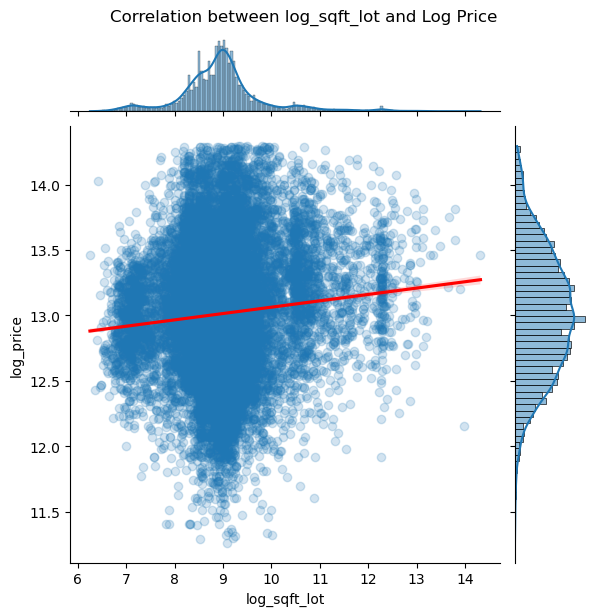

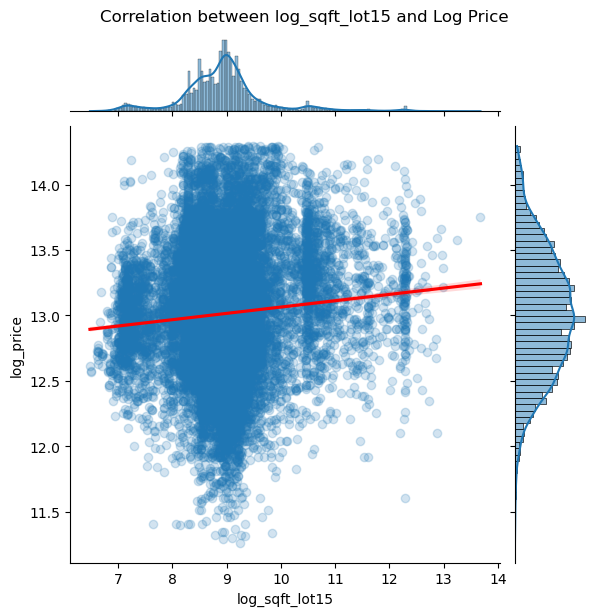

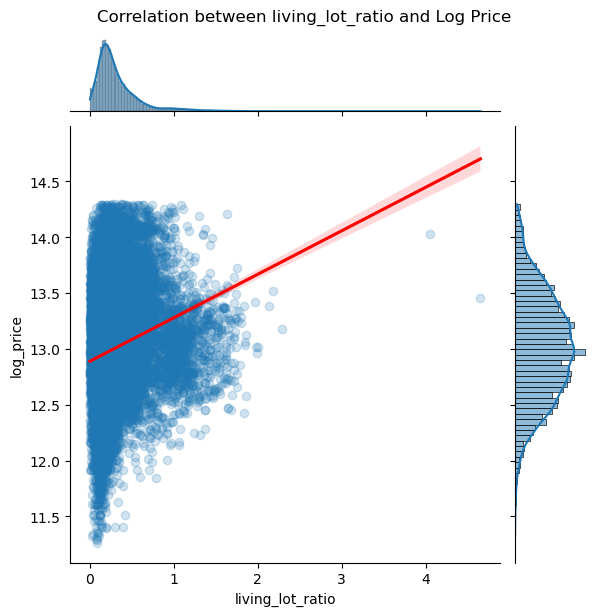

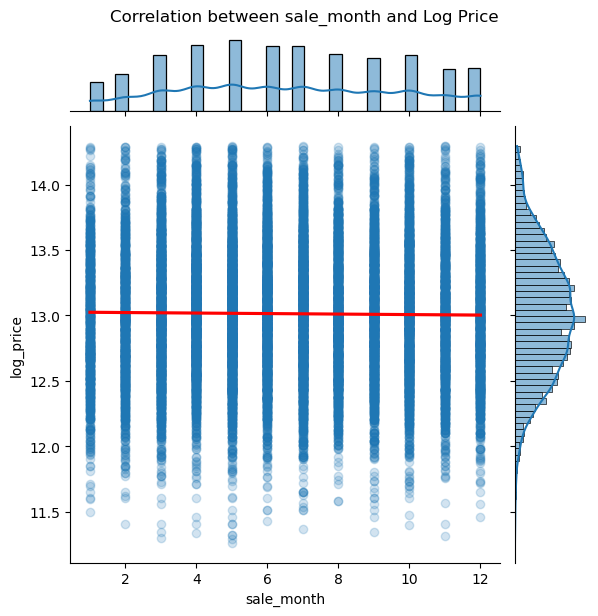

In [185]:
top_features = df.select_dtypes(include=['number']).columns

for feature in top_features:
    sns.jointplot(data=df, x=feature, y='log_price', kind='reg', 
                  scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
    plt.suptitle(f'Correlation between {feature} and Log Price', y=1.02)
    plt.show()

# Curated charts

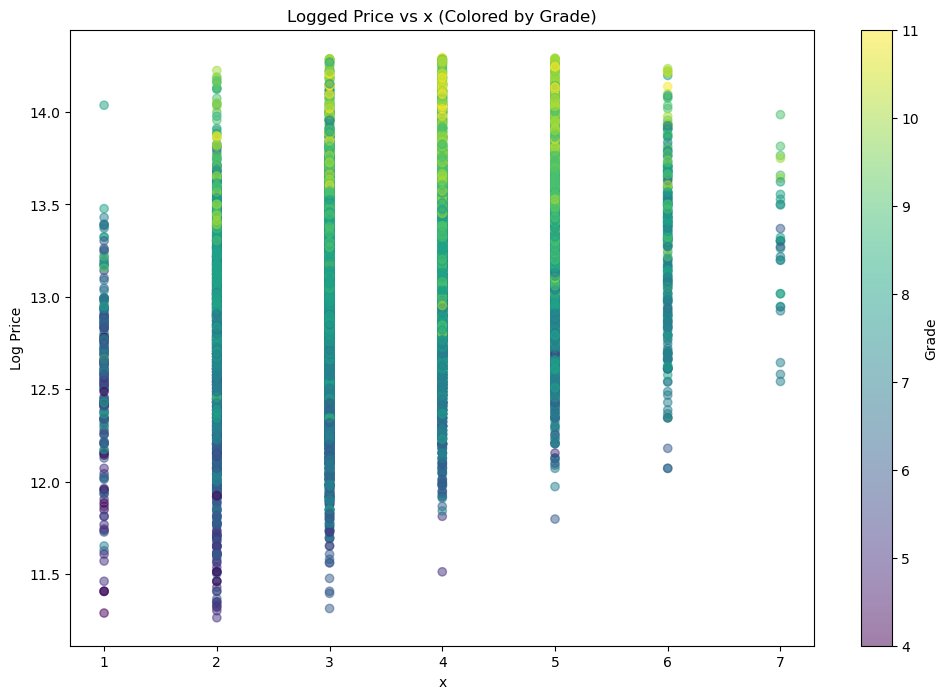

In [186]:
x = df['bedrooms']
y = df['log_price']
color = df['grade']

plt.figure(figsize=(12, 8))
plt.scatter(x, y, c = color, alpha = 0.5)
plt.colorbar(label='Grade')
plt.xlabel('x')
plt.ylabel('Log Price')
plt.title('Logged Price vs x (Colored by Grade)')
plt.show()

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21096 entries, 0 to 21095
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             21096 non-null  float64
 1   bedrooms          21096 non-null  int64  
 2   bathrooms         21096 non-null  float64
 3   sqft_living       21096 non-null  int64  
 4   sqft_lot          21096 non-null  float64
 5   floors            21096 non-null  float64
 6   waterfront        21096 non-null  int64  
 7   view              21096 non-null  int64  
 8   condition         21096 non-null  int64  
 9   grade             21096 non-null  int64  
 10  sqft_above        21096 non-null  int64  
 11  sqft_basement     21096 non-null  int64  
 12  sqft_living15     21096 non-null  int64  
 13  sqft_lot15        21096 non-null  int64  
 14  house_age         21096 non-null  int64  
 15  renovated_bool    21096 non-null  int64  
 16  log_price         21096 non-null  float6

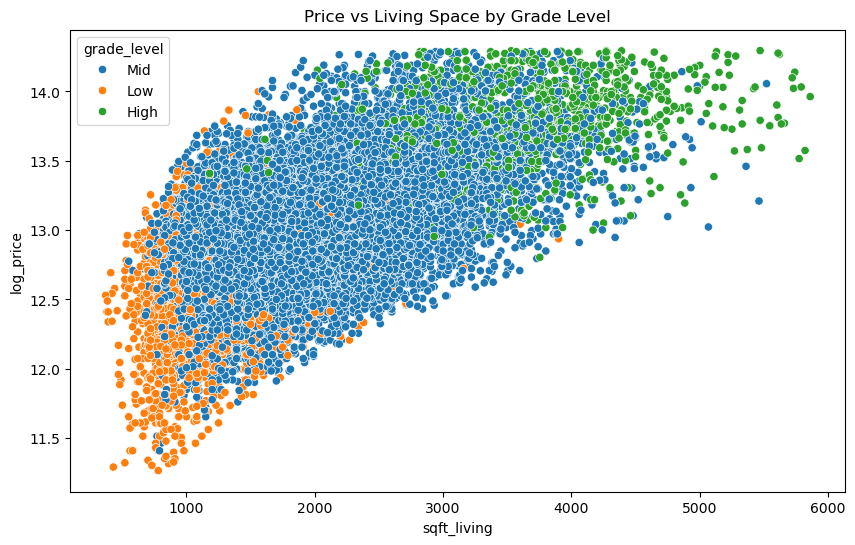

In [213]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sqft_living', y='log_price', hue='grade_level')
plt.title('Price vs Living Space by Grade Level')
plt.show()